In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount("/content/drive")

SEED = 42

PROJECT_DIR = Path("/content/drive/MyDrive/DSAI305_XAI_Project")

INCEPTION_DIR = PROJECT_DIR / "results_inceptionresnetv2_notebook1"
DENSENET_DIR = PROJECT_DIR / "results_densenet121_notebook2"
CONVNEXT_DIR = PROJECT_DIR / "results_convnexttiny_notebook3"

ENSEMBLE_DIR = PROJECT_DIR / "results_bonus_ensemble_inception_densenet_convnext"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("InceptionResNetV2 directory:", INCEPTION_DIR)
print("DenseNet121 directory:", DENSENET_DIR)
print("ConvNeXtTiny directory:", CONVNEXT_DIR)
print("Ensemble outputs will be saved to:", ENSEMBLE_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/DSAI305_XAI_Project
InceptionResNetV2 directory: /content/drive/MyDrive/DSAI305_XAI_Project/results_inceptionresnetv2_notebook1
DenseNet121 directory: /content/drive/MyDrive/DSAI305_XAI_Project/results_densenet121_notebook2
ConvNeXtTiny directory: /content/drive/MyDrive/DSAI305_XAI_Project/results_convnexttiny_notebook3
Ensemble outputs will be saved to: /content/drive/MyDrive/DSAI305_XAI_Project/results_bonus_ensemble_inception_densenet_convnext


In [2]:
def load_class_indices(results_dir):
    class_indices_path = results_dir / "class_indices.json"

    if not class_indices_path.exists():
        raise FileNotFoundError(f"Missing class_indices.json in {results_dir}")

    with open(class_indices_path, "r") as f:
        class_indices = json.load(f)

    index_to_class = {int(v): k for k, v in class_indices.items()}
    class_names = [index_to_class[i] for i in range(len(index_to_class))]

    return class_indices, index_to_class, class_names


def load_npy_file(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return np.load(path)


# Load class orders
inception_class_indices, index_to_class, class_names = load_class_indices(INCEPTION_DIR)
densenet_class_indices, _, _ = load_class_indices(DENSENET_DIR)
convnext_class_indices, _, _ = load_class_indices(CONVNEXT_DIR)

if inception_class_indices != densenet_class_indices:
    raise ValueError("Class index mismatch between InceptionResNetV2 and DenseNet121.")

if inception_class_indices != convnext_class_indices:
    raise ValueError("Class index mismatch between InceptionResNetV2 and ConvNeXtTiny.")

print("Classes:")
for i, cls in enumerate(class_names):
    print(i, ":", cls)


# Standard predictions
inception_probs = load_npy_file(INCEPTION_DIR / "inceptionresnetv2_test_pred_probs.npy")
densenet_probs = load_npy_file(DENSENET_DIR / "densenet121_test_pred_probs.npy")
convnext_probs = load_npy_file(CONVNEXT_DIR / "convnexttiny_test_pred_probs.npy")

# TTA predictions
inception_tta_probs = load_npy_file(INCEPTION_DIR / "inceptionresnetv2_tta_test_pred_probs.npy")
densenet_tta_probs = load_npy_file(DENSENET_DIR / "densenet121_tta_test_pred_probs.npy")
convnext_tta_probs = load_npy_file(CONVNEXT_DIR / "convnexttiny_tta_test_pred_probs.npy")

# y_true
inception_y_true = load_npy_file(INCEPTION_DIR / "inceptionresnetv2_test_y_true.npy")
densenet_y_true = load_npy_file(DENSENET_DIR / "densenet121_test_y_true.npy")
convnext_y_true = load_npy_file(CONVNEXT_DIR / "convnexttiny_test_y_true.npy")

print("Shapes:")
print("InceptionResNetV2:", inception_probs.shape)
print("DenseNet121:", densenet_probs.shape)
print("ConvNeXtTiny:", convnext_probs.shape)
print("y_true:", inception_y_true.shape)

Classes:
0 : 00 Anatomia Normal
1 : 01 Processos Inflamatórios Pulmonares (Pneumonia)
2 : 02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)
3 : 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)
4 : 04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)
5 : 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)
6 : 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)
7 : 07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)
8 : 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)
Shapes:
InceptionResNetV2: (1012, 9)
DenseNet121: (1012, 9)
ConvNeXtTiny: (1012, 9)
y_true: (1012,)


In [5]:
def check_same_shape(*arrays):
    shapes = [arr.shape for arr in arrays]
    if len(set(shapes)) != 1:
        raise ValueError(f"Shape mismatch: {shapes}")
    print("All probability arrays have same shape:", shapes[0])


def check_same_y_true(y1, y2, y3):
    if not np.array_equal(y1, y2):
        raise ValueError("InceptionResNetV2 y_true and DenseNet121 y_true are not identical.")

    if not np.array_equal(y1, y3):
        raise ValueError("InceptionResNetV2 y_true and ConvNeXtTiny y_true are not identical.")

    print("All y_true arrays are identical.")


check_same_shape(
    inception_probs,
    densenet_probs,
    convnext_probs,
    inception_tta_probs,
    densenet_tta_probs,
    convnext_tta_probs
)

check_same_y_true(
    inception_y_true,
    densenet_y_true,
    convnext_y_true
)

y_true = inception_y_true
num_classes = len(class_names)

print("Number of test samples:", len(y_true))
print("Number of classes:", num_classes)

All probability arrays have same shape: (1012, 9)
All y_true arrays are identical.
Number of test samples: 1012
Number of classes: 9


In [6]:
def evaluate_probs(y_true, probs, model_name):
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)

    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": f1_macro,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro
    }


def print_report(y_true, probs, title):
    y_pred = np.argmax(probs, axis=1)

    print("=" * 80)
    print(title)
    print("=" * 80)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print()

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))


def normalize_weights(weights):
    weights = np.array(weights, dtype=np.float32)
    return weights / weights.sum()


def weighted_ensemble(probs_list, weights):
    weights = normalize_weights(weights)

    ensemble_probs = np.zeros_like(probs_list[0], dtype=np.float32)

    for probs, weight in zip(probs_list, weights):
        ensemble_probs += weight * probs

    return ensemble_probs

In [7]:
results = []

# Standard individual models
results.append(evaluate_probs(y_true, inception_probs, "InceptionResNetV2 Standard"))
results.append(evaluate_probs(y_true, densenet_probs, "DenseNet121 Standard"))
results.append(evaluate_probs(y_true, convnext_probs, "ConvNeXtTiny Standard"))

# TTA individual models
results.append(evaluate_probs(y_true, inception_tta_probs, "InceptionResNetV2 TTA"))
results.append(evaluate_probs(y_true, densenet_tta_probs, "DenseNet121 TTA"))
results.append(evaluate_probs(y_true, convnext_tta_probs, "ConvNeXtTiny TTA"))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)

display(results_df)

results_df.to_csv(
    ENSEMBLE_DIR / "individual_model_comparison.csv",
    index=False
)

,model,accuracy,macro_f1,macro_precision,macro_recall
0,InceptionResNetV2 TTA,0.968379,0.972847,0.970803,0.976736
1,DenseNet121 Standard,0.967391,0.971629,0.971017,0.973380
2,DenseNet121 TTA,0.966403,0.970491,0.967554,0.975038
3,ConvNeXtTiny TTA,0.961462,0.967481,0.966750,0.970805
4,ConvNeXtTiny Standard,0.958498,0.965370,0.962928,0.968330
5,InceptionResNetV2 Standard,0.958498,0.963318,0.960708,0.968130


In [8]:
standard_soft_probs = weighted_ensemble(
    probs_list=[
        inception_probs,
        densenet_probs,
        convnext_probs
    ],
    weights=[1, 1, 1]
)

standard_soft_result = evaluate_probs(
    y_true,
    standard_soft_probs,
    "Standard Soft Voting Ensemble"
)

print(standard_soft_result)

print_report(
    y_true,
    standard_soft_probs,
    "Standard Soft Voting Ensemble"
)

np.save(
    ENSEMBLE_DIR / "standard_soft_voting_probs.npy",
    standard_soft_probs
)

{'model': 'Standard Soft Voting Ensemble', 'accuracy': 0.9733201581027668, 'macro_f1': 0.9773858497076877, 'macro_precision': 0.9760982773674031, 'macro_recall': 0.9793368199741315}
Standard Soft Voting Ensemble
Accuracy: 0.9733201581027668
Macro F1: 0.9773858497076877

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal     0.9612    0.9851    0.9730       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)     0.9589    0.8805    0.9180       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)     1.0000    1.0000    1.0000       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)     0.9694    1.0000    0.9845        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquie

In [9]:
tta_soft_probs = weighted_ensemble(
    probs_list=[
        inception_tta_probs,
        densenet_tta_probs,
        convnext_tta_probs
    ],
    weights=[1, 1, 1]
)

tta_soft_result = evaluate_probs(
    y_true,
    tta_soft_probs,
    "TTA Soft Voting Ensemble"
)

print(tta_soft_result)

print_report(
    y_true,
    tta_soft_probs,
    "TTA Soft Voting Ensemble"
)

np.save(
    ENSEMBLE_DIR / "tta_soft_voting_probs.npy",
    tta_soft_probs
)

{'model': 'TTA Soft Voting Ensemble', 'accuracy': 0.9723320158102767, 'macro_f1': 0.9762178339786381, 'macro_precision': 0.9744197997213908, 'macro_recall': 0.9793853142379911}
TTA Soft Voting Ensemble
Accuracy: 0.9723320158102767
Macro F1: 0.9762178339786381

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal     0.9567    0.9900    0.9731       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)     0.9784    0.8553    0.9128       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)     1.0000    1.0000    1.0000       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)     0.9694    1.0000    0.9845        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Em

In [10]:
manual_weights = {
    "InceptionResNetV2": 0.40,
    "DenseNet121": 0.40,
    "ConvNeXtTiny": 0.20
}

manual_weighted_tta_probs = weighted_ensemble(
    probs_list=[
        inception_tta_probs,
        densenet_tta_probs,
        convnext_tta_probs
    ],
    weights=[
        manual_weights["InceptionResNetV2"],
        manual_weights["DenseNet121"],
        manual_weights["ConvNeXtTiny"]
    ]
)

manual_weighted_tta_result = evaluate_probs(
    y_true,
    manual_weighted_tta_probs,
    "Manual Weighted TTA Ensemble"
)

print("Manual weights:")
print(manual_weights)
print()

print(manual_weighted_tta_result)

print_report(
    y_true,
    manual_weighted_tta_probs,
    "Manual Weighted TTA Ensemble"
)

np.save(
    ENSEMBLE_DIR / "manual_weighted_tta_ensemble_probs.npy",
    manual_weighted_tta_probs
)

Manual weights:
{'InceptionResNetV2': 0.4, 'DenseNet121': 0.4, 'ConvNeXtTiny': 0.2}

{'model': 'Manual Weighted TTA Ensemble', 'accuracy': 0.974308300395257, 'macro_f1': 0.9774345444040257, 'macro_precision': 0.9750358342540559, 'macro_recall': 0.9812296016298375}
Manual Weighted TTA Ensemble
Accuracy: 0.974308300395257
Macro F1: 0.9774345444040257

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal     0.9707    0.9900    0.9803       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)     0.9786    0.8616    0.9164       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)     1.0000    1.0000    1.0000       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)     0.9794    1.0000    0.9896   

In [11]:
weight_candidates = np.arange(0.05, 1.00, 0.05)

search_rows = []

for wi in weight_candidates:
    for wd in weight_candidates:
        for wc in weight_candidates:
            weights_sum = wi + wd + wc

            if abs(weights_sum - 1.0) > 1e-6:
                continue

            probs = weighted_ensemble(
                probs_list=[
                    inception_tta_probs,
                    densenet_tta_probs,
                    convnext_tta_probs
                ],
                weights=[wi, wd, wc]
            )

            y_pred = np.argmax(probs, axis=1)

            acc = accuracy_score(y_true, y_pred)
            f1_macro = f1_score(y_true, y_pred, average="macro")
            precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
            recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)

            search_rows.append({
                "inceptionresnetv2_weight": wi,
                "densenet121_weight": wd,
                "convnexttiny_weight": wc,
                "accuracy": acc,
                "macro_f1": f1_macro,
                "macro_precision": precision_macro,
                "macro_recall": recall_macro
            })

weights_search_df = pd.DataFrame(search_rows)

weights_search_df = weights_search_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

display(weights_search_df.head(20))

weights_search_df.to_csv(
    ENSEMBLE_DIR / "tta_weight_search_results.csv",
    index=False
)

best_row = weights_search_df.iloc[0]

best_weights = {
    "InceptionResNetV2": float(best_row["inceptionresnetv2_weight"]),
    "DenseNet121": float(best_row["densenet121_weight"]),
    "ConvNeXtTiny": float(best_row["convnexttiny_weight"])
}

print("Best weights:")
print(best_weights)

print("Best Macro F1:", best_row["macro_f1"])
print("Best Accuracy:", best_row["accuracy"])

,inceptionresnetv2_weight,densenet121_weight,convnexttiny_weight,accuracy,macro_f1,macro_precision,macro_recall
0,0.35,0.50,0.15,0.976285,0.978959,0.976728,0.982481
1,0.40,0.50,0.10,0.976285,0.978959,0.976728,0.982481
2,0.40,0.55,0.05,0.976285,0.978959,0.976728,0.982481
3,0.50,0.40,0.10,0.975296,0.978469,0.976333,0.981928
4,0.50,0.45,0.05,0.975296,0.978469,0.976333,0.981928
5,0.55,0.40,0.05,0.975296,0.978469,0.976333,0.981928
6,0.45,0.50,0.05,0.975296,0.978289,0.976185,0.981782
7,0.35,0.55,0.10,0.975296,0.978128,0.975627,0.981928
8,0.35,0.45,0.20,0.975296,0.978105,0.975581,0.981928
9,0.40,0.45,0.15,0.975296,0.978105,0.975581,0.981928


Best weights:
{'InceptionResNetV2': 0.35000000000000003, 'DenseNet121': 0.5, 'ConvNeXtTiny': 0.15000000000000002}
Best Macro F1: 0.97895890141298
Best Accuracy: 0.9762845849802372


In [12]:
best_weighted_tta_probs = weighted_ensemble(
    probs_list=[
        inception_tta_probs,
        densenet_tta_probs,
        convnext_tta_probs
    ],
    weights=[
        best_weights["InceptionResNetV2"],
        best_weights["DenseNet121"],
        best_weights["ConvNeXtTiny"]
    ]
)

best_weighted_tta_result = evaluate_probs(
    y_true,
    best_weighted_tta_probs,
    "Best Weighted TTA Ensemble"
)

print("Best weights:")
print(best_weights)
print()

print(best_weighted_tta_result)

print_report(
    y_true,
    best_weighted_tta_probs,
    "Best Weighted TTA Ensemble"
)

np.save(
    ENSEMBLE_DIR / "best_weighted_tta_ensemble_probs.npy",
    best_weighted_tta_probs
)

Best weights:
{'InceptionResNetV2': 0.35000000000000003, 'DenseNet121': 0.5, 'ConvNeXtTiny': 0.15000000000000002}

{'model': 'Best Weighted TTA Ensemble', 'accuracy': 0.9762845849802372, 'macro_f1': 0.97895890141298, 'macro_precision': 0.9767282691983605, 'macro_recall': 0.9824812052469719}
Best Weighted TTA Ensemble
Accuracy: 0.9762845849802372
Macro F1: 0.97895890141298

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal     0.9756    0.9950    0.9852       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)     0.9787    0.8679    0.9200       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)     1.0000    1.0000    1.0000       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)     0.989

In [13]:
final_results = []

# Individual standard
final_results.append(evaluate_probs(y_true, inception_probs, "InceptionResNetV2 Standard"))
final_results.append(evaluate_probs(y_true, densenet_probs, "DenseNet121 Standard"))
final_results.append(evaluate_probs(y_true, convnext_probs, "ConvNeXtTiny Standard"))

# Individual TTA
final_results.append(evaluate_probs(y_true, inception_tta_probs, "InceptionResNetV2 TTA"))
final_results.append(evaluate_probs(y_true, densenet_tta_probs, "DenseNet121 TTA"))
final_results.append(evaluate_probs(y_true, convnext_tta_probs, "ConvNeXtTiny TTA"))

# Ensembles
final_results.append(evaluate_probs(y_true, standard_soft_probs, "Standard Soft Voting Ensemble"))
final_results.append(evaluate_probs(y_true, tta_soft_probs, "TTA Soft Voting Ensemble"))
final_results.append(evaluate_probs(y_true, manual_weighted_tta_probs, "Manual Weighted TTA Ensemble"))
final_results.append(evaluate_probs(y_true, best_weighted_tta_probs, "Best Weighted TTA Ensemble"))

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

display(final_results_df)

final_results_df.to_csv(
    ENSEMBLE_DIR / "final_model_and_ensemble_comparison.csv",
    index=False
)

,model,accuracy,macro_f1,macro_precision,macro_recall
0,Best Weighted TTA Ensemble,0.976285,0.978959,0.976728,0.982481
1,Manual Weighted TTA Ensemble,0.974308,0.977435,0.975036,0.981230
2,Standard Soft Voting Ensemble,0.973320,0.977386,0.976098,0.979337
3,TTA Soft Voting Ensemble,0.972332,0.976218,0.974420,0.979385
4,InceptionResNetV2 TTA,0.968379,0.972847,0.970803,0.976736
5,DenseNet121 Standard,0.967391,0.971629,0.971017,0.973380
6,DenseNet121 TTA,0.966403,0.970491,0.967554,0.975038
7,ConvNeXtTiny TTA,0.961462,0.967481,0.966750,0.970805
8,ConvNeXtTiny Standard,0.958498,0.965370,0.962928,0.968330
9,InceptionResNetV2 Standard,0.958498,0.963318,0.960708,0.968130


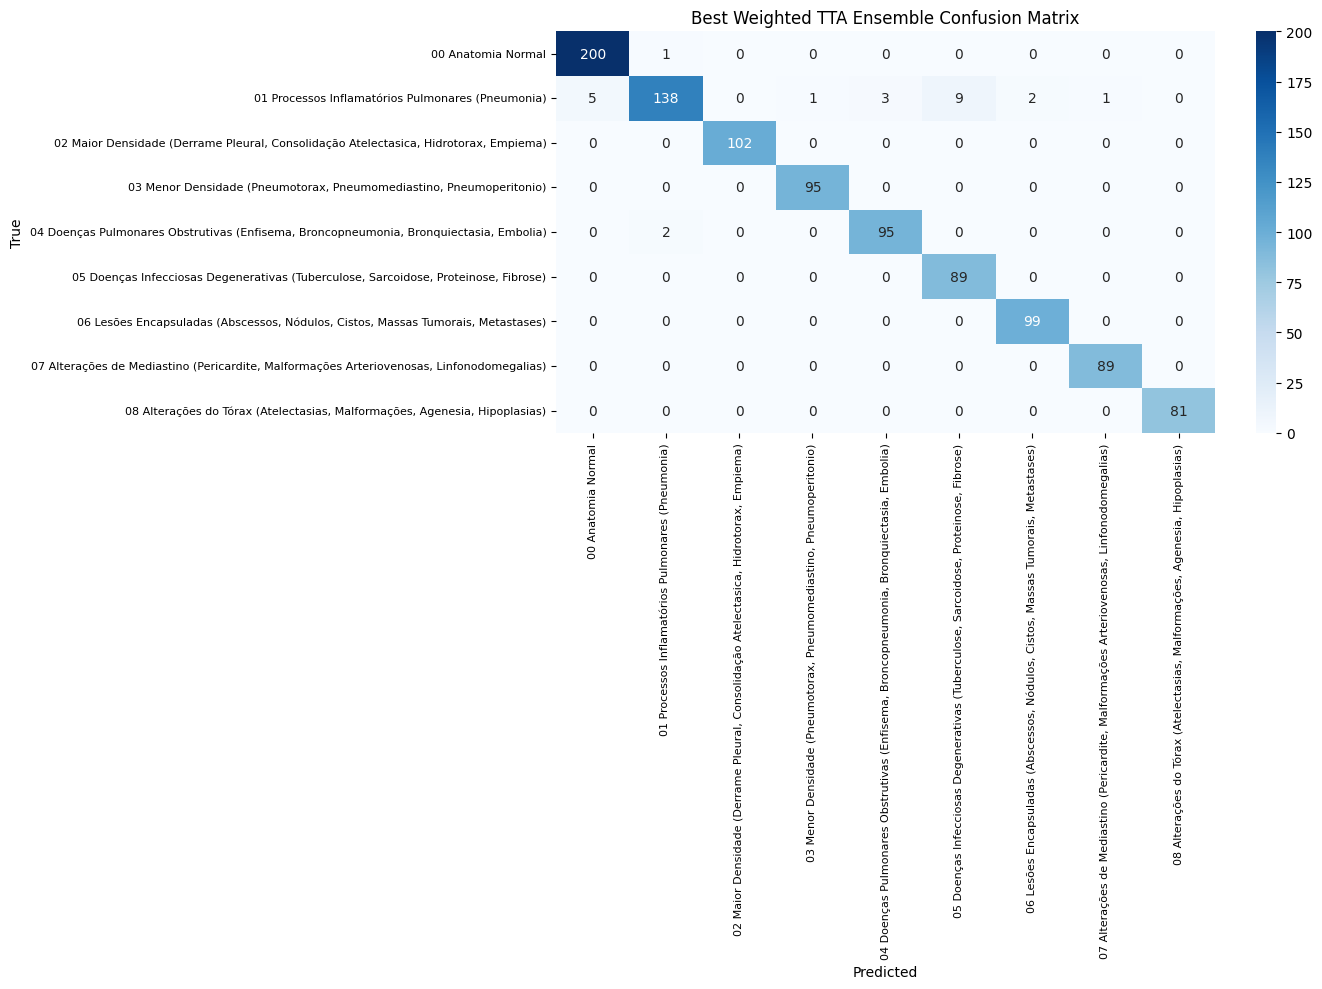

In [14]:
best_ensemble_pred = np.argmax(best_weighted_tta_probs, axis=1)

best_cm = confusion_matrix(y_true, best_ensemble_pred)

plt.figure(figsize=(14, 10))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Best Weighted TTA Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

plt.savefig(
    ENSEMBLE_DIR / "best_weighted_tta_ensemble_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [15]:
def per_class_metrics(y_true, probs, model_name):
    y_pred = np.argmax(probs, axis=1)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    rows = []

    for cls in class_names:
        rows.append({
            "model": model_name,
            "class": cls,
            "precision": report_dict[cls]["precision"],
            "recall": report_dict[cls]["recall"],
            "f1_score": report_dict[cls]["f1-score"],
            "support": report_dict[cls]["support"]
        })

    return pd.DataFrame(rows)


# Compare strongest individual TTA model against best ensemble
individual_tta_results = pd.DataFrame([
    evaluate_probs(y_true, inception_tta_probs, "InceptionResNetV2 TTA"),
    evaluate_probs(y_true, densenet_tta_probs, "DenseNet121 TTA"),
    evaluate_probs(y_true, convnext_tta_probs, "ConvNeXtTiny TTA")
])

best_single_model_name = individual_tta_results.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
).iloc[0]["model"]

print("Best single TTA model:", best_single_model_name)

if best_single_model_name == "InceptionResNetV2 TTA":
    best_single_probs = inception_tta_probs
elif best_single_model_name == "DenseNet121 TTA":
    best_single_probs = densenet_tta_probs
else:
    best_single_probs = convnext_tta_probs

best_single_per_class = per_class_metrics(
    y_true,
    best_single_probs,
    best_single_model_name
)

ensemble_per_class = per_class_metrics(
    y_true,
    best_weighted_tta_probs,
    "Best Weighted TTA Ensemble"
)

per_class_comparison_df = pd.concat(
    [best_single_per_class, ensemble_per_class],
    axis=0
).reset_index(drop=True)

display(per_class_comparison_df)

per_class_comparison_df.to_csv(
    ENSEMBLE_DIR / "per_class_comparison_best_single_vs_best_ensemble.csv",
    index=False
)

Best single TTA model: InceptionResNetV2 TTA


,model,class,precision,recall,f1_score,support
0,InceptionResNetV2 TTA,00 Anatomia Normal,0.951923,0.985075,0.968215,201.0
1,InceptionResNetV2 TTA,01 Processos Inflamatórios Pulmonares (Pneumonia),0.977941,0.836478,0.901695,159.0
2,InceptionResNetV2 TTA,"02 Maior Densidade (Derrame Pleural, Consolida...",1.000000,1.000000,1.000000,102.0
3,InceptionResNetV2 TTA,"03 Menor Densidade (Pneumotorax, Pneumomediast...",0.979381,1.000000,0.989583,95.0
4,InceptionResNetV2 TTA,"04 Doenças Pulmonares Obstrutivas (Enfisema, B...",0.921569,0.969072,0.944724,97.0
5,InceptionResNetV2 TTA,05 Doenças Infecciosas Degenerativas (Tubercul...,0.917526,1.000000,0.956989,89.0
6,InceptionResNetV2 TTA,"06 Lesões Encapsuladas (Abscessos, Nódulos, Ci...",1.000000,1.000000,1.000000,99.0
7,InceptionResNetV2 TTA,"07 Alterações de Mediastino (Pericardite, Malf...",0.988889,1.000000,0.994413,89.0
8,InceptionResNetV2 TTA,"08 Alterações do Tórax (Atelectasias, Malforma...",1.000000,1.000000,1.000000,81.0
9,Best Weighted TTA Ensemble,00 Anatomia Normal,0.975610,0.995025,0.985222,201.0


In [16]:
def bootstrap_metric_ci(y_true, probs, metric_fn, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    scores = []

    for _ in range(n_bootstrap):
        indices = rng.choice(n, size=n, replace=True)

        y_true_sample = y_true[indices]
        probs_sample = probs[indices]
        y_pred_sample = np.argmax(probs_sample, axis=1)

        score = metric_fn(y_true_sample, y_pred_sample)
        scores.append(score)

    scores = np.array(scores)

    return {
        "mean": float(np.mean(scores)),
        "ci_lower_95": float(np.percentile(scores, 2.5)),
        "ci_upper_95": float(np.percentile(scores, 97.5))
    }


def metric_accuracy(y_true_sample, y_pred_sample):
    return accuracy_score(y_true_sample, y_pred_sample)


def metric_macro_f1(y_true_sample, y_pred_sample):
    return f1_score(y_true_sample, y_pred_sample, average="macro")


ci_rows = []

models_for_ci = [
    ("InceptionResNetV2 TTA", inception_tta_probs),
    ("DenseNet121 TTA", densenet_tta_probs),
    ("ConvNeXtTiny TTA", convnext_tta_probs),
    ("Best Weighted TTA Ensemble", best_weighted_tta_probs)
]

for model_name, probs in models_for_ci:
    acc_ci = bootstrap_metric_ci(
        y_true,
        probs,
        metric_accuracy,
        n_bootstrap=1000
    )

    f1_ci = bootstrap_metric_ci(
        y_true,
        probs,
        metric_macro_f1,
        n_bootstrap=1000
    )

    ci_rows.append({
        "model": model_name,
        "accuracy_mean": acc_ci["mean"],
        "accuracy_ci_lower_95": acc_ci["ci_lower_95"],
        "accuracy_ci_upper_95": acc_ci["ci_upper_95"],
        "macro_f1_mean": f1_ci["mean"],
        "macro_f1_ci_lower_95": f1_ci["ci_lower_95"],
        "macro_f1_ci_upper_95": f1_ci["ci_upper_95"]
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)

ci_df.to_csv(
    ENSEMBLE_DIR / "bootstrap_confidence_intervals.csv",
    index=False
)

,model,accuracy_mean,accuracy_ci_lower_95,accuracy_ci_upper_95,macro_f1_mean,macro_f1_ci_lower_95,macro_f1_ci_upper_95
0,InceptionResNetV2 TTA,0.968312,0.957510,0.979249,0.972683,0.963821,0.981558
1,DenseNet121 TTA,0.966452,0.955534,0.977273,0.970425,0.960810,0.980225
2,ConvNeXtTiny TTA,0.961592,0.948617,0.974308,0.967487,0.957207,0.977873
3,Best Weighted TTA Ensemble,0.976299,0.967391,0.985178,0.978893,0.970639,0.987061


In [17]:
ensemble_summary = {
    "project": "DSAI305 Healthcare XAI Project",
    "bonus_component": "Advanced weighted soft-voting ensemble",
    "models_used": [
        "InceptionResNetV2",
        "DenseNet121",
        "ConvNeXtTiny"
    ],
    "input_files": {
        "inceptionresnetv2_tta_probs": str(INCEPTION_DIR / "inceptionresnetv2_tta_test_pred_probs.npy"),
        "densenet121_tta_probs": str(DENSENET_DIR / "densenet121_tta_test_pred_probs.npy"),
        "convnexttiny_tta_probs": str(CONVNEXT_DIR / "convnexttiny_tta_test_pred_probs.npy")
    },
    "manual_weights": manual_weights,
    "best_weights_from_grid_search": best_weights,
    "best_ensemble_result": best_weighted_tta_result,
    "outputs": {
        "final_comparison": str(ENSEMBLE_DIR / "final_model_and_ensemble_comparison.csv"),
        "weight_search": str(ENSEMBLE_DIR / "tta_weight_search_results.csv"),
        "confusion_matrix": str(ENSEMBLE_DIR / "best_weighted_tta_ensemble_confusion_matrix.png"),
        "per_class_comparison": str(ENSEMBLE_DIR / "per_class_comparison_best_single_vs_best_ensemble.csv"),
        "bootstrap_ci": str(ENSEMBLE_DIR / "bootstrap_confidence_intervals.csv")
    },
    "bonus_justification": {
        "advanced_model_design": "The final system combines three different deep learning architectures using weighted soft voting.",
        "methodological_innovation": "The ensemble uses TTA probabilities and grid search for optimal model weights.",
        "research_level_validation": "The notebook reports per-class performance and bootstrap confidence intervals."
    }
}

with open(ENSEMBLE_DIR / "bonus_ensemble_metadata.json", "w") as f:
    json.dump(ensemble_summary, f, indent=2)

print("Bonus ensemble metadata saved.")
print(json.dumps(ensemble_summary, indent=2))

Bonus ensemble metadata saved.
{
  "project": "DSAI305 Healthcare XAI Project",
  "bonus_component": "Advanced weighted soft-voting ensemble",
  "models_used": [
    "InceptionResNetV2",
    "DenseNet121",
    "ConvNeXtTiny"
  ],
  "input_files": {
    "inceptionresnetv2_tta_probs": "/content/drive/MyDrive/DSAI305_XAI_Project/results_inceptionresnetv2_notebook1/inceptionresnetv2_tta_test_pred_probs.npy",
    "densenet121_tta_probs": "/content/drive/MyDrive/DSAI305_XAI_Project/results_densenet121_notebook2/densenet121_tta_test_pred_probs.npy",
    "convnexttiny_tta_probs": "/content/drive/MyDrive/DSAI305_XAI_Project/results_convnexttiny_notebook3/convnexttiny_tta_test_pred_probs.npy"
  },
  "manual_weights": {
    "InceptionResNetV2": 0.4,
    "DenseNet121": 0.4,
    "ConvNeXtTiny": 0.2
  },
  "best_weights_from_grid_search": {
    "InceptionResNetV2": 0.35000000000000003,
    "DenseNet121": 0.5,
    "ConvNeXtTiny": 0.15000000000000002
  },
  "best_ensemble_result": {
    "model": "Best